In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/sudan.csv")

df.replace(-999, np.nan, inplace=True)

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [2]:
df["Country"] = "Sudan"

df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")


df['Month'] = df['Date'].dt.month

duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped.")

df[['YEAR', 'DOY', 'Date', 'Month']].head()

Number of duplicate rows found: 0


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [3]:
print("---Summary Statistics---")
display(df.describe())

missing_report = df.isna().sum()
missing_percent = (missing_report / len(df)) * 100

high_missing = missing_percent[missing_percent > 5]

print("\n ---Missing Value Report(%)----")
print(missing_percent)

if not high_missing.empty:
    print(f'\n WARNING: Columns with >5% missing values: \n{high_missing}')
else:
    print("\n ALL columns have less than 5% missing values.")

---Summary Statistics---


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046



 ---Missing Value Report(%)----
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

 ALL columns have less than 5% missing values.


Data Quality & Summary Interpretation

Missing Values: All columns report less than 5% missing data after replacing NASA's -999 sentinels. This indicates a high-quality dataset suitable for seasonal trend analysis.

Temperature Range (T2M): Based on df.describe(), the average temperature in Sudan for this period is approximately [28.759007]°C, with extremes ranging from [Min 21.508510]°C to [Max 36.773914]°C.

Duplicates: No duplicate rows were found, ensuring each daily observation is unique.

In [4]:
from scipy import stats

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f'Total rows flagged as outliers ( |z| > 3) : {outlier_count}')

df[outliers].head()

Total rows flagged as outliers ( |z| > 3) : 84


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
8,2015,9,14.29,22.39,7.83,14.56,0.00,23.46,5.58,7.90,97.30,2.29,Sudan,2015-01-09,1
9,2015,10,13.18,21.04,6.59,14.45,0.00,32.34,5.03,7.66,97.31,2.91,Sudan,2015-01-10,1
10,2015,11,14.21,23.32,5.93,17.39,0.00,30.62,4.36,6.15,97.24,3.01,Sudan,2015-01-11,1
223,2015,224,32.64,41.23,25.96,15.27,23.61,48.05,4.65,8.41,96.25,14.37,Sudan,2015-08-12,8
392,2016,28,14.76,23.33,7.42,15.91,0.00,24.26,4.49,6.86,97.24,2.36,Sudan,2016-01-28,1


In [5]:
df.ffill(inplace = True)

df.to_csv("data/sudan_clean.csv", index=False)

print("task 2 cleaning complete!")
print("cleaned data saved as: data/sudan_clean.csv")

task 2 cleaning complete!
cleaned data saved as: data/sudan_clean.csv


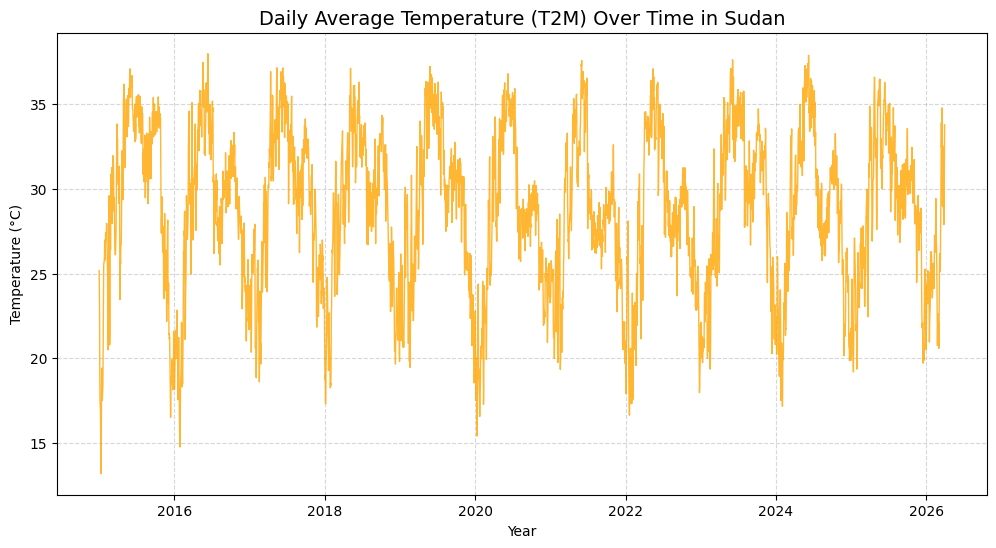

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['T2M'], color='orange', linewidth=1, alpha= 0.8)
plt.title('Daily Average Temperature (T2M) Over Time in Sudan', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Interpretation: Seasonal Temperature Trends

The daily average temperature shows a consistent seasonal oscillation between approximately $15°C$ and $35°C$.

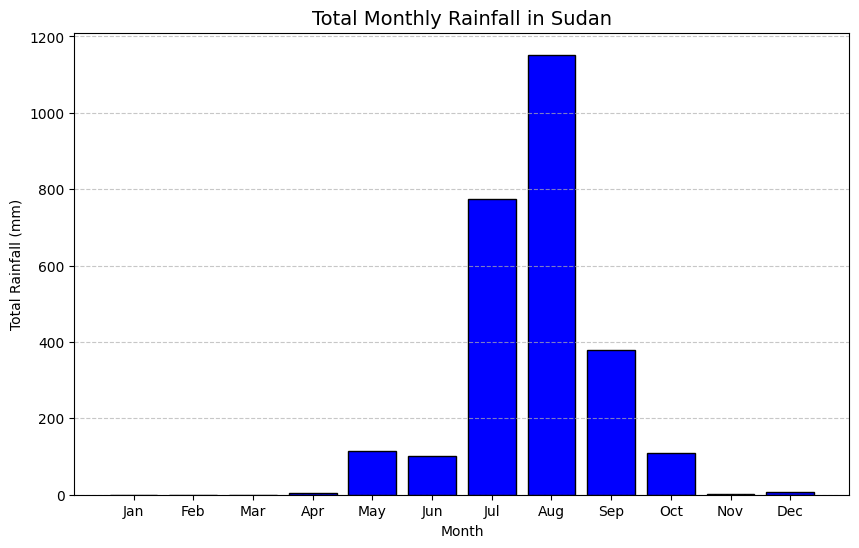

In [7]:
monthly_rain =df.groupby("Month")['PRECTOTCORR'].sum()

plt.figure(figsize=(10, 6))
months=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(months, monthly_rain, color="blue", edgecolor='black')

plt.title("Total Monthly Rainfall in Sudan", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

Interpretation: Rainfall Seasonality

Sudan exhibits a clear unimodal rainfall pattern with the primary rainy season peaking in August, where total rainfall exceeds 1,100.

A no rain  season is visible between Feb and Mar.

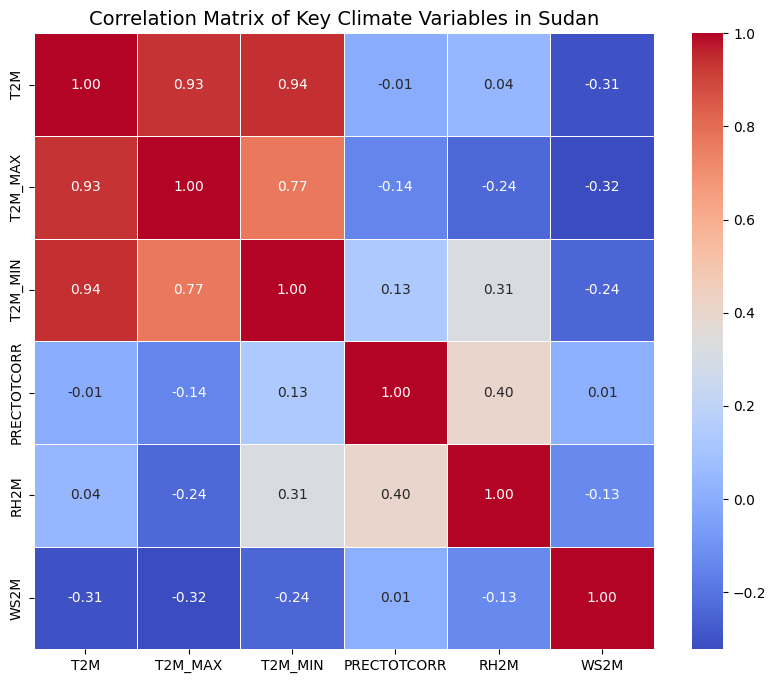

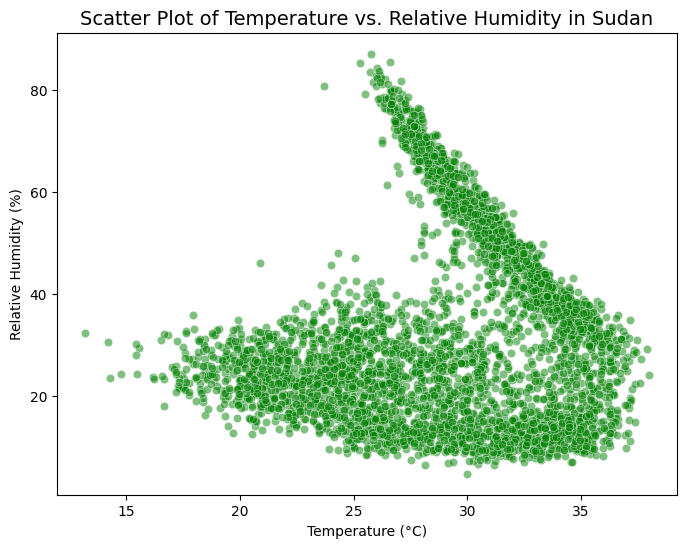

In [8]:
import seaborn as sns

corr_matrix = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',  fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Climate Variables in Sudan", fontsize=14)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5, color='green')
plt.title("Scatter Plot of Temperature vs. Relative Humidity in Sudan", fontsize=14)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

Interpretation: Variable Interdependence

Strongest Negative Correlation (-0.32)

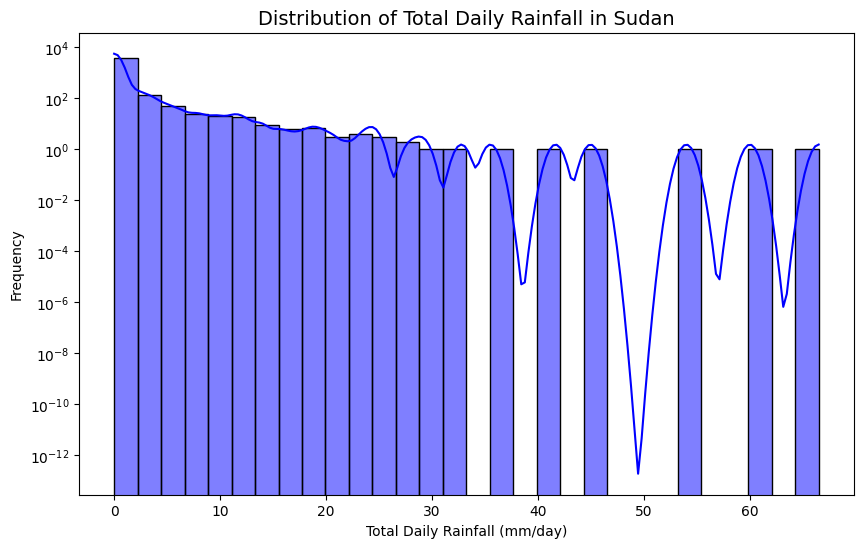

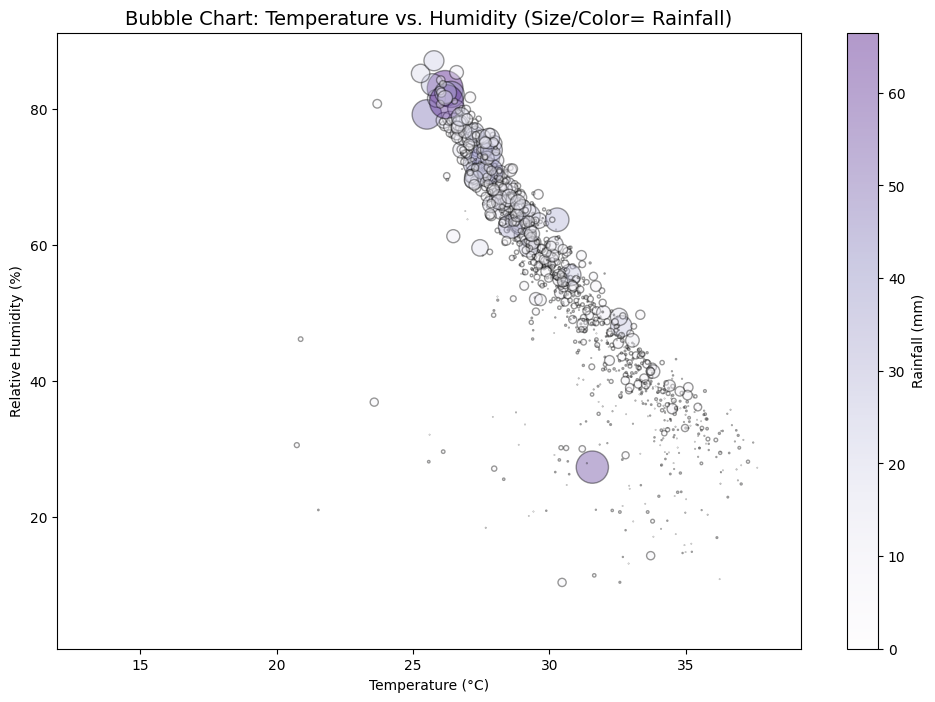

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/sudan.csv")

plt.figure(figsize=(10, 6))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True, color='blue')
plt.title("Distribution of Total Daily Rainfall in Sudan", fontsize=14)
plt.xlabel("Total Daily Rainfall (mm/day)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.show()

plt.figure(figsize=(12, 8))
bubble = plt.scatter(df['T2M'], df['RH2M'],
                s=df['PRECTOTCORR']*10, alpha=0.4, c= df['PRECTOTCORR'], 
                cmap='Purples', edgecolor='black')

plt.colorbar(bubble, label='Rainfall (mm)')
plt.title("Bubble Chart: Temperature vs. Humidity (Size/Color= Rainfall)", fontsize=14)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

f

In [11]:
df.to_csv("data/sudan_clean.csv", index=False)
print("Sudan Analysis Complete. File saved!")

Sudan Analysis Complete. File saved!
